# Iterované vězňovo dilema

In [2]:
import random

import numpy as np

from deap import base, creator, tools, algorithms

## Strategie odpovědí
obecně jde o funkci tvaru *zrada(moje_historie_tahu, druheho_historie_tahu)* pro seznam minulých rozhodnutí vrátí, zda protihráče v následujícím tahu zradíme (1) nebo ne (0)

- první parametr je seznam historie našich tahů
- druhý parametr je seznam historie tahů protihráče


In [3]:

# vždy kooperuje
def always_cooperate(myhistory, otherhistory):
    return 0

def always_notcooperate(myhistory, otherhistory):
    return 1

# náhodná odpověď
def random_answer(myhistory, otherhistory):
    p = random.random()
    if p < 0.5:
        return 1
    
    return 0
    
    



## Pomocné funkce

In [4]:
def rozdej_skore(tah1, tah2):
    # 1 = zradi, 0 = nezradi
    
    skores = (0, 0)
    
    if (tah1 == 1) and (tah2 == 1):
        skores = (2, 2)

    if (tah1 == 1) and (tah2 == 0):
        skores = (0, 3)    
    
    if (tah1 == 0) and (tah2 == 1):
        skores = (3, 0)
        
    if (tah1 == 0) and (tah2 == 0):
        skores = (1, 1)
                
    return skores    
        
        
def play(f1, f2, stepsnum):
    
    skore1 = 0
    skore2 = 0
    
    historie1 = []
    historie2 = []
    
    for i in range(stepsnum):
        tah1 = f1(historie1, historie2)
        tah2 = f2(historie2, historie1)

        s1, s2 = rozdej_skore(tah1, tah2)
        skore1 += s1
        skore2 += s2
        
        historie1.append(tah1)
        historie2.append(tah2)
       
    return skore1, skore2



## Evoluce strategie

In [5]:
# místo pro vlastní evoluci strategie

C:\Users\pavel\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\pavel\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	mean   	min
0  	100   	1422.08	950
1  	77    	1287.37	950
2  	85    	1159.08	950
3  	82    	1096.33	950
4  	83    	1019.73	950
5  	85    	974.07 	950
6  	87    	953.55 	950
7  	86    	955.08 	950
8  	82    	952.68 	950
9  	85    	950.3  	950
10 	85    	955.11 	950
11 	87    	950.2  	950
12 	84    	952.35 	950
13 	90    	952.35 	950
14 	87    	950    	950
15 	81    	952.43 	950
16 	79    	952.53 	950
17 	90    	952.78 	950
18 	87    	950.2  	950
19 	81    	952.44 	950
20 	86    	960.39 	950
21 	84    	950.1  	950
22 	90    	950    	950
23 	85    	957.13 	950
24 	90    	950.3  	950
25 	88    	957.59 	950
26 	84    	952.35 	950
27 	86    	950.2  	950
28 	87    	955.12 	950
29 	90    	960.02 	950
30 	83    	952.44 	950
31 	83    	950.2  	950
32 	83    	950.2  	950
33 	87    	954.93 	950
34 	85    	952.63 	950
35 	83    	950    	950
36 	82    	952.53 	950
37 	90    	952.43 	950
38 	88    	959.55 	950
39 	84    	952.54 	950
40 	84    	950    	950
41 	87    	952.44 	950
42 	81    	

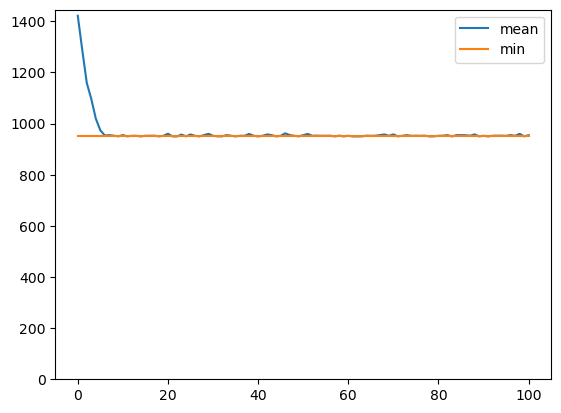

In [6]:
import numpy as np

import random as rnd

from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt



nOpponent = 10

NGEN = 100         # počet generací

N = 6


#Create opponents
opponents = []

for i in range(nOpponent):
    
    opp = []
    for j in range(NGEN):
        opp.append(rnd.randint(0,1))

    opponents.append(opp)




creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

creator.create("Individual", list, fitness=creator.FitnessMin)


toolbox = base.Toolbox()

toolbox.register("attr_int", rnd.randint,0,1)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_int, n=N)


toolbox.register("population", tools.initRepeat, list, toolbox.individual) 


def evaluate(individual):

    score = 0
    
    def f1(historie1, historie2):
        currRound = len(historie1)-2

        if(currRound==-2):
            return individual[0]
        if(currRound==-1):
            return individual[1]
    
        if (historie2[currRound] == 1) and (historie2[currRound-1] == 1):
            return individual[2]

        if (historie2[currRound] == 1) and (historie2[currRound-1] == 0):
            return individual[3]   

        if (historie2[currRound] == 0) and (historie2[currRound-1] == 1):
            return individual[4]

        if (historie2[currRound] == 0) and (historie2[currRound-1] == 0):
            return individual[5]
        
    for opp in opponents:
        
        def f2(historie1, historie2):
            currRound = len(historie1)
            return opp[currRound] 
        
        skore1, skore2=play(f1, f2, NGEN)
        
        score+= skore1
                 
    return score, # !!!! vracíme n-tici, proto ta čárka
   
    
toolbox.register("evaluate", evaluate)


toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=1, indpb=0.01)
toolbox.register("select", tools.selTournament, tournsize=2)



CXPB = 0.5           # pravděpodobnost crossoveru na páru
MUTPB = 0.7         # pravděpodobnost mutace



s = tools.Statistics(key=lambda ind: ind.fitness.values)
s.register("mean", np.mean)
s.register("min", np.min)

hof = tools.HallOfFame(3)

pop = toolbox.population(n=100)


finalpop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=s, halloffame=hof)

#%%
# plot
mean, minimum = logbook.select("mean", "min")

fig, ax = plt.subplots()

ax.plot(range(NGEN+1), mean, label="mean")     # 0.tá generace zvlášť
ax.plot(range(NGEN+1), minimum, label="min")
ax.set_ylim(ymin=0)
ax.legend()

print(hof)


## Moje funkce

In [5]:
# vlastní funkce zrada(moje_historie_tahu, druheho_historie_tahu)
# zadrátovaná dle 

In [ ]:
def jayBond(historie1, historie2):
        individual = [1, 1, 1, 1, 1, 1]

        currRound = len(historie1)-2

        if(currRound==-2):
            return individual[0]
        if(currRound==-1):
            return individual[1]
    
        if (historie2[currRound] == 1) and (historie2[currRound-1] == 1):
            return individual[2]

        if (historie2[currRound] == 1) and (historie2[currRound-1] == 0):
            return individual[3]   

        if (historie2[currRound] == 0) and (historie2[currRound-1] == 1):
            return individual[4]

        if (historie2[currRound] == 0) and (historie2[currRound-1] == 0):
            return individual[5]

## Turnaj

In [13]:

        
# seznam funkci o testování
ucastnici = [always_cooperate, random_answer, always_notcooperate]

# funkce se mohou v seznamu i opakovat 
#ucastnici = [always_cooperate, always_cooperate, random_answer, random_answer, random_answer]



STEPSNUM = 20


l = len(ucastnici)
skores = [0 for i in range(l)]

print("=========================================")
print("Turnaj")
print("hra délky:", STEPSNUM)
print("-----------------------------------------")


for i in range(l):
    for j in range(i+1, l):
        f1 = ucastnici[i]
        f2 = ucastnici[j]
        skore1, skore2 = play(f1, f2, STEPSNUM)
        print(f1.__name__, "x", f2.__name__, " ", skore1, ":", skore2)
        skores[i] += skore1
        skores[j] += skore2
        

print("=========================================")
print("= Výsledné pořadí")
print("-----------------------------------------")


# setrideni indexu vysledku
index = sorted(range(l), key=lambda k: skores[k])

poradi = 1
for i in index:
    f = ucastnici[i]
    print(poradi, ".", f.__name__, ":", skores[i])
    poradi += 1
        
        

Turnaj
hra délky: 20
-----------------------------------------
always_cooperate x random_answer   34 : 13
always_cooperate x always_notcooperate   60 : 0
random_answer x always_notcooperate   53 : 14
= Výsledné pořadí
-----------------------------------------
1 . always_notcooperate : 14
2 . random_answer : 66
3 . always_cooperate : 94
